In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# HIGH-SPEED LOCAL DATA CACHE
# ==========================================
print("Copying dataset from Google Drive to Colab Local SSD (This takes ~60 seconds)...")
!cp -r /content/drive/MyDrive/FER_Project/dataset/archive/train /content/fast_train_data
print(" Data successfully copied to local high-speed storage!")

Copying dataset from Google Drive to Colab Local SSD (This takes ~60 seconds)...
 Data successfully copied to local high-speed storage!


In [ ]:
# ==========================================
# CELL 1: ENVIRONMENT & SEEDING
# ==========================================
!pip install -q timm torch_geometric

import os
import cv2
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.preprocessing import LabelEncoder, StandardScaler
import timm
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm

# Lock down random seeds for absolute reproducibility
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Environment Initialized. Computation Device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.6 MB/s eta 0:00:00
 Environment Initialized. Computation Device: cuda


In [ ]:
# ==========================================
# CELL 2: DUAL-STREAM DATA PIPELINE (ANTI-DEADLOCK)
# ==========================================
import os
import cv2
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Structurally Safe Augmentations
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class RobustHybridDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform

        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.df['label'])

        feature_cols = [col for col in self.df.columns if col not in ['image_name', 'label']]
        self.scaler = StandardScaler()
        self.geom_features = self.scaler.fit_transform(self.df[feature_cols].values)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Image Pathing
        img_name = str(self.df.iloc[idx]['image_name'])
        str_label = str(self.df.iloc[idx]['label'])
        img_path = os.path.join(self.image_dir, str_label, img_name)

        # Image Loading
        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        # Geometric & Label
        geom = torch.tensor(self.geom_features[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, geom, label

# 2. Initialization
GCN_CSV_PATH = '/content/drive/MyDrive/FER_Project/gcn_structural_features.csv'
#  THE FIX: Pointing to the lightning-fast local Colab storage
IMAGE_FOLDER_PATH = '/content/fast_train_data'

dataset = RobustHybridDataset(GCN_CSV_PATH, IMAGE_FOLDER_PATH, transform=train_transform)

# 3. Splitting & Loaders
train_size = int(0.85 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform

# Batch size 16 (saves memory) and num_workers 0 (prevents CPU freezing)
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f" Data Pipeline Ready (Anti-Deadlock Mode). Classes: {dataset.label_encoder.classes_}")

 Data Pipeline Ready (Anti-Deadlock Mode). Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']


In [ ]:
# ==========================================
# CELL 3: THE SOTA DUAL-STREAM MODEL
# ==========================================
class SOTAHybridFER(nn.Module):
    def __init__(self, num_classes=7):
        super(SOTAHybridFER, self).__init__()

        # --- STREAM 1: VISUAL ---
        self.convnext = timm.create_model('convnext_tiny', pretrained=True, num_classes=0, global_pool='')
        self.embed_dim = 768

        encoder_layer = nn.TransformerEncoderLayer(d_model=self.embed_dim, nhead=8, batch_first=True, dim_feedforward=2048)
        self.vit = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.vis_norm = nn.LayerNorm(self.embed_dim) # Prevents Modality Collapse

        # --- STREAM 2: GEOMETRIC ---
        self.geom_node_embed = nn.Linear(1, 64)
        self.gcn_attention = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        self.geom_pool = nn.Linear(6 * 64, 128)
        self.geom_norm = nn.LayerNorm(128) # Prevents Modality Collapse

        # --- FUSION CLASSIFIER ---
        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim + 128, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.5), # Increased dropout for better regularization
            nn.Linear(512, num_classes)
        )

    def forward(self, image, geom_features):
        b = image.shape[0]

        # Visual Stream
        x_vis = self.convnext(image)
        _, c, h, w = x_vis.shape
        x_vis = x_vis.view(b, c, h * w).transpose(1, 2)
        x_vis = self.vit(x_vis)
        x_vis = x_vis.mean(dim=1)
        x_vis = self.vis_norm(x_vis) # Normalize visual features

        # Geometric Stream
        x_geom = geom_features.unsqueeze(-1)
        x_geom = self.geom_node_embed(x_geom)
        x_geom_attn, _ = self.gcn_attention(x_geom, x_geom, x_geom)
        x_geom = x_geom + x_geom_attn
        x_geom = x_geom.reshape(b, -1)
        x_geom = F.relu(self.geom_pool(x_geom))
        x_geom = self.geom_norm(x_geom) # Normalize geometric features

        # Fusion
        fused = torch.cat((x_vis, x_geom), dim=1)
        return self.classifier(fused)

model = SOTAHybridFER(num_classes=len(dataset.label_encoder.classes_)).to(device)
print(" SOTA Architecture Built Successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

 SOTA Architecture Built Successfully.


In [ ]:
# ==========================================
# CELL 4: THE MASTER TRAINING ENGINE
# ==========================================
EPOCHS = 50
BASE_LR = 1e-4

# Label Smoothing prevents the model from being "too confident" on ambiguous faces
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Differential Learning Rates: ConvNeXt learns slower, new layers learn faster
optimizer = optim.AdamW([
    {'params': model.convnext.parameters(), 'lr': BASE_LR / 5},
    {'params': model.vit.parameters(), 'lr': BASE_LR},
    {'params': model.geom_node_embed.parameters(), 'lr': BASE_LR},
    {'params': model.gcn_attention.parameters(), 'lr': BASE_LR},
    {'params': model.geom_pool.parameters(), 'lr': BASE_LR},
    {'params': model.classifier.parameters(), 'lr': BASE_LR}
], weight_decay=0.01)

# Cosine Annealing with Warm Restarts (Bounces the LR to prevent getting stuck)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

scaler = GradScaler('cuda')
best_val_accuracy = 0.0
MODEL_SAVE_PATH = '/content/drive/MyDrive/FER_Project/hybrid_fer_master.pth'

print(f" Igniting Master Engine for {EPOCHS} Epochs...\n")

for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for images, geom, labels in loop:
        images, geom, labels = images.to(device), geom.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast('cuda'):
            outputs = model(images, geom)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    scheduler.step()
    train_acc = (train_correct / train_total) * 100

    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, geom, labels in val_loader:
            images, geom, labels = images.to(device), geom.to(device), labels.to(device)
            with autocast('cuda'):
                outputs = model(images, geom)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = (val_correct / val_total) * 100
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Time: {epoch_time:.0f}s | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_accuracy:
        print(f"   NEW SOTA: {val_acc:.2f}%! Checkpoint saved.")
        best_val_accuracy = val_acc
        torch.save({'model_state_dict': model.state_dict()}, MODEL_SAVE_PATH)

print(f"\n Master Training Complete! Final Best Accuracy: {best_val_accuracy:.2f}%")

 Igniting Master Engine for 50 Epochs...



Epoch 1/50:   0%|          | 0/1212 [00:00<?, ?it/s]

Epoch 01/50 | Time: 206s | Train Acc: 72.00% | Val Acc: 81.96%
   NEW SOTA: 81.96%! Checkpoint saved.


Epoch 2/50:   0%|          | 0/1212 [00:00<?, ?it/s]

Epoch 02/50 | Time: 176s | Train Acc: 90.82% | Val Acc: 90.28%
   NEW SOTA: 90.28%! Checkpoint saved.


...

Epoch 48/50 | Time: 172s | Train Acc: 99.65% | Val Acc: 94.57%


Epoch 49/50:   0%|          | 0/1212 [00:00<?, ?it/s]

Epoch 49/50 | Time: 172s | Train Acc: 99.69% | Val Acc: 95.74%


Epoch 50/50:   0%|          | 0/1212 [00:00<?, ?it/s]

Epoch 50/50 | Time: 172s | Train Acc: 99.42% | Val Acc: 95.15%

 Master Training Complete! Final Best Accuracy: 96.53%


In [ ]:
!pip install torchmetrics seaborn scikit-learn matplotlib

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.2 MB/s eta 0:00:00


Best model loaded successfully

Inference complete

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


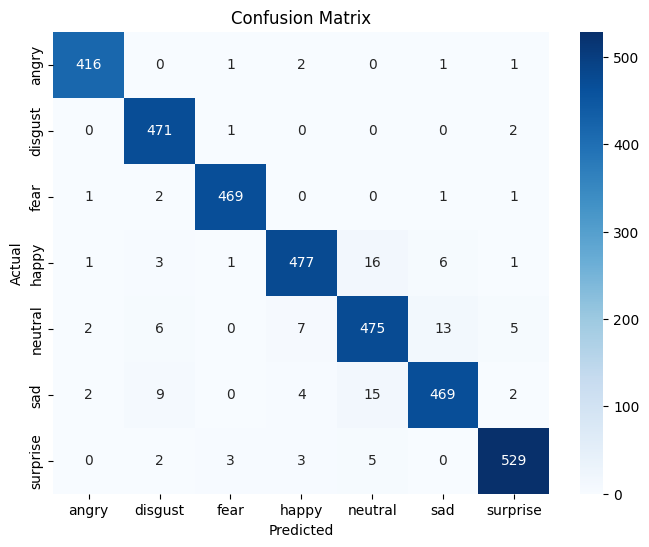


Classification Report:

              precision    recall  f1-score   support

       angry       0.99      0.99      0.99       421
     disgust       0.96      0.99      0.97       474
        fear       0.99      0.99      0.99       474
       happy       0.97      0.94      0.96       505
     neutral       0.93      0.94      0.93       508
         sad       0.96      0.94      0.95       501
    surprise       0.98      0.98      0.98       542

    accuracy                           0.97      3425
   macro avg       0.97      0.97      0.97      3425
weighted avg       0.97      0.97      0.97      3425


 Overall Metrics:
Accuracy : 0.9653
Precision: 0.9653
Recall   : 0.9653
F1 Score : 0.9652


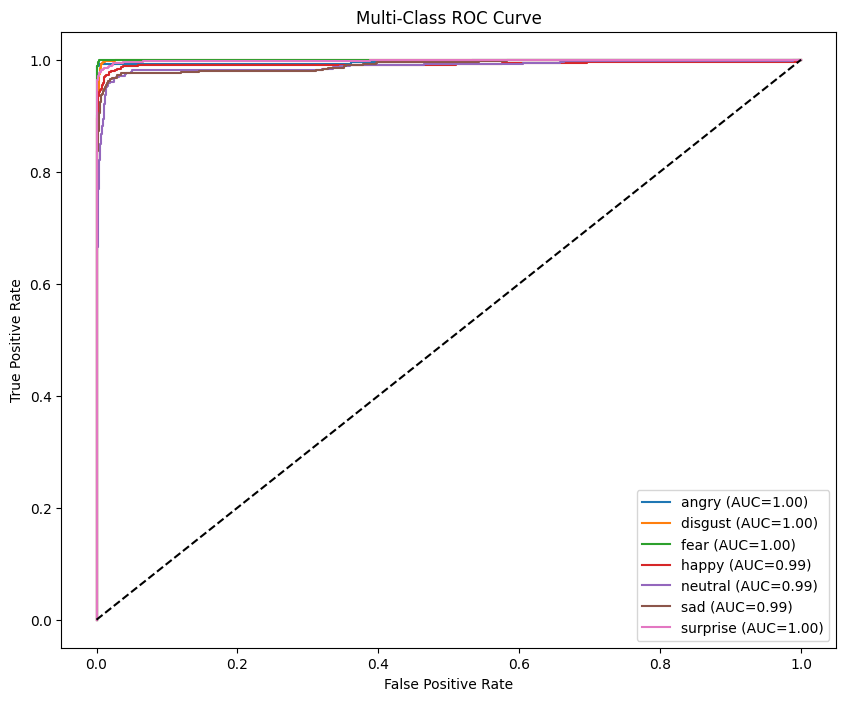


 Per-Class Accuracy:
angry: 0.9881
disgust: 0.9937
fear: 0.9895
happy: 0.9446
neutral: 0.9350
sad: 0.9361
surprise: 0.9760


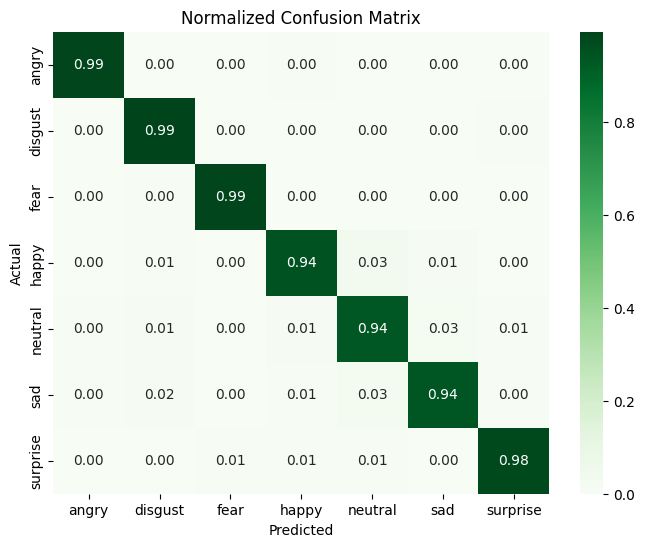

In [ ]:
# ==========================================
# CELL 5: EVALUATION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)

# -------- LOAD BEST MODEL --------
MODEL_SAVE_PATH = '/content/drive/MyDrive/FER_Project/hybrid_fer_master.pth'

checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print("Best model loaded successfully\n")

# -------- USE VALIDATION AS TEST --------
eval_loader = val_loader   # <- IMPORTANT FIX

# -------- INFERENCE --------
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, geom, labels in eval_loader:
        images = images.to(device)
        geom = geom.to(device)

        outputs = model(images, geom)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)
y_prob = np.array(all_probs)

print("Inference complete\n")

# -------- CLASS NAMES (FROM YOUR PIPELINE) --------
class_names = list(dataset.label_encoder.classes_)
print("Classes:", class_names)

# ==========================================
# 1. CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==========================================
# 2. CLASSIFICATION REPORT
# ==========================================
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# ==========================================
# 3. OVERALL METRICS
# ==========================================
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n Overall Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# ==========================================
# 4. ROC CURVE (MULTI-CLASS)
# ==========================================
plt.figure(figsize=(10,8))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true == i, y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# ==========================================
# 5. PER-CLASS ACCURACY
# ==========================================
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print("\n Per-Class Accuracy:")
for i, acc in enumerate(per_class_acc):
    print(f"{class_names[i]}: {acc:.4f}")

# ==========================================
# 6. NORMALIZED CONFUSION MATRIX (PAPER USE)
# ==========================================
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")
plt.show()

In [ ]:
# ==========================================
# UNIVERSAL TRAINER & TIMING ENGINE (UPDATED WITH PROGRESS BAR)
# ==========================================
import time
import numpy as np
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm # Added for progress tracking

def run_ablation_experiment(model_name, model, train_loader, val_loader, device, epochs=15):
    print(f"\n{'='*50}\n Running Experiment: {model_name}\n{'='*50}")
    model = model.to(device)

    # Standard Optimizer & Loss
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
    scaler = GradScaler('cuda')

    best_val_acc = 0.0

    # --- TRAINING LOOP ---
    for epoch in range(epochs):
        model.train()

        # ADDED PROGRESS BAR HERE
        loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{epochs}")
        for images, geom, labels in loop:
            images, geom, labels = images.to(device), geom.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast('cuda'):
                outputs = model(images, geom)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # Update progress bar with current loss
            loop.set_postfix(loss=loss.item())

        scheduler.step()

        # --- VALIDATION LOOP ---
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, geom, labels in val_loader:
                images, geom, labels = images.to(device), geom.to(device), labels.to(device)
                with autocast('cuda'):
                    outputs = model(images, geom)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = (val_correct / val_total) * 100
        print(f"Epoch {epoch+1:02d}/{epochs} completed. Validation Accuracy: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc

    print(f" Best Validation Accuracy for {model_name}: {best_val_acc:.2f}%")

    # --- EXECUTION TIME (LATENCY) CALCULATION ---
    print(f" Calculating Execution Time...")
    dummy_img = torch.randn(1, 3, 224, 224).to(device) # Single image batch
    dummy_geo = torch.randn(1, 6).to(device)

    # GPU Warmup
    for _ in range(10):
        _ = model(dummy_img, dummy_geo)

    # High Precision Timing using CUDA Events
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    timings = []

    with torch.no_grad():
        for _ in range(100): # Test 100 times for a stable average
            starter.record()
            _ = model(dummy_img, dummy_geo)
            ender.record()
            torch.cuda.synchronize() # Wait for GPU to finish
            timings.append(starter.elapsed_time(ender))

    avg_latency_ms = np.mean(timings)
    fps = 1000 / avg_latency_ms
    print(f" Inference Latency: {avg_latency_ms:.2f} ms per frame ({fps:.0f} FPS)")

    return best_val_acc, avg_latency_ms

print(" Ablation Engine Ready with Progress Bars.")

 Ablation Engine Ready with Progress Bars.


In [ ]:
# ==========================================
# CELL 6: THE ABLATION STUDY & LATENCY ENGINE
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import timm
import time
import numpy as np
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm

print(" Building Ablation Architectures...")

num_classes = len(dataset.label_encoder.classes_)

# 1. VISUAL STREAM ONLY
class VisualOnlyFER(nn.Module):
    def __init__(self, num_classes):
        super(VisualOnlyFER, self).__init__()
        self.convnext = timm.create_model('convnext_tiny', pretrained=True, num_classes=0, global_pool='')
        self.embed_dim = 768
        encoder_layer = nn.TransformerEncoderLayer(d_model=self.embed_dim, nhead=8, batch_first=True, dim_feedforward=2048)
        self.vit = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Sequential(
            nn.Linear(768, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(0.5), nn.Linear(512, num_classes)
        )

    def forward(self, image, geom_features):
        b = image.shape[0]
        x = self.convnext(image)
        _, c, h, w = x.shape
        x = x.view(b, c, h * w).transpose(1, 2)
        x = self.vit(x)
        x = x.mean(dim=1)
        return self.classifier(x)

# 2. GEOMETRIC STREAM ONLY
class GeometricOnlyFER(nn.Module):
    def __init__(self, num_classes):
        super(GeometricOnlyFER, self).__init__()
        self.geom_node_embed = nn.Linear(1, 64)
        self.gcn_attention = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        self.geom_pool = nn.Linear(6 * 64, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(0.3), nn.Linear(64, num_classes)
        )

    def forward(self, image, geom_features):
        b = geom_features.shape[0]
        x = geom_features.unsqueeze(-1)
        x = self.geom_node_embed(x)
        x_attn, _ = self.gcn_attention(x, x, x)
        x = x + x_attn
        x = x.reshape(b, -1)
        x = F.relu(self.geom_pool(x))
        return self.classifier(x)

# 3. DUAL-STREAM WITHOUT LAYERNORM (Modality Collapse Test)
class NoNormHybridFER(nn.Module):
    def __init__(self, num_classes):
        super(NoNormHybridFER, self).__init__()
        self.convnext = timm.create_model('convnext_tiny', pretrained=True, num_classes=0, global_pool='')
        self.embed_dim = 768
        encoder_layer = nn.TransformerEncoderLayer(d_model=self.embed_dim, nhead=8, batch_first=True, dim_feedforward=2048)
        self.vit = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.geom_node_embed = nn.Linear(1, 64)
        self.gcn_attention = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        self.geom_pool = nn.Linear(6 * 64, 128)
        # Missing LayerNorm before concatenation!
        self.classifier = nn.Sequential(
            nn.Linear(768 + 128, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(0.5), nn.Linear(512, num_classes)
        )

    def forward(self, image, geom_features):
        b = image.shape[0]
        x_vis = self.convnext(image)
        _, c, h, w = x_vis.shape
        x_vis = x_vis.view(b, c, h * w).transpose(1, 2)
        x_vis = self.vit(x_vis)
        x_vis = x_vis.mean(dim=1)

        x_geom = geom_features.unsqueeze(-1)
        x_geom = self.geom_node_embed(x_geom)
        x_geom_attn, _ = self.gcn_attention(x_geom, x_geom, x_geom)
        x_geom = x_geom + x_geom_attn
        x_geom = x_geom.reshape(b, -1)
        x_geom = F.relu(self.geom_pool(x_geom))

        fused = torch.cat((x_vis, x_geom), dim=1)
        return self.classifier(fused)

# --- TRAINING ENGINE ---
def run_ablation_experiment(model_name, test_model, train_loader, val_loader, device, epochs=15):
    print(f"\n{'='*50}\n Running Ablation: {model_name}\n{'='*50}")
    test_model = test_model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(test_model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
    scaler = GradScaler('cuda')

    best_val_acc = 0.0

    for epoch in range(epochs):
        test_model.train()
        loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{epochs}")
        for images, geom, labels in loop:
            images, geom, labels = images.to(device), geom.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast('cuda'):
                outputs = test_model(images, geom)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loop.set_postfix(loss=loss.item())
        scheduler.step()

        test_model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, geom, labels in val_loader:
                images, geom, labels = images.to(device), geom.to(device), labels.to(device)
                with autocast('cuda'):
                    outputs = test_model(images, geom)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = (val_correct / val_total) * 100
        print(f"Epoch {epoch+1:02d}/{epochs} | Val Acc: {val_acc:.2f}%")
        if val_acc > best_val_acc:
            best_val_acc = val_acc

    print(f" Calculating Execution Latency...")
    dummy_img = torch.randn(1, 3, 224, 224).to(device)
    dummy_geo = torch.randn(1, 6).to(device)
    for _ in range(10):
        _ = test_model(dummy_img, dummy_geo)

    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    timings = []
    with torch.no_grad():
        for _ in range(100):
            starter.record()
            _ = test_model(dummy_img, dummy_geo)
            ender.record()
            torch.cuda.synchronize()
            timings.append(starter.elapsed_time(ender))

    avg_latency_ms = np.mean(timings)
    return best_val_acc, avg_latency_ms

# --- EXECUTE ---
ablation_models = {
    "1. Visual Stream Only": VisualOnlyFER(num_classes),
    "2. Geometric Stream Only": GeometricOnlyFER(num_classes),
    "3. Dual-Stream (NO LayerNorm)": NoNormHybridFER(num_classes)
}

results = {}
for name, abl_model in ablation_models.items():
    acc, latency = run_ablation_experiment(name, abl_model, train_loader, val_loader, device, epochs=15)
    results[name] = {"Accuracy": acc, "Latency (ms)": latency}

# --- GET MASTER MODEL LATENCY ---
print(f"\n{'='*50}\n Calculating Master Model Latency...\n{'='*50}")
dummy_img = torch.randn(1, 3, 224, 224).to(device)
dummy_geo = torch.randn(1, 6).to(device)
for _ in range(10): _ = model(dummy_img, dummy_geo)
starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
timings = []
with torch.no_grad():
    for _ in range(100):
        starter.record()
        _ = model(dummy_img, dummy_geo)
        ender.record()
        torch.cuda.synchronize()
        timings.append(starter.elapsed_time(ender))
master_latency = np.mean(timings)

# --- PRINT FINAL TABLE ---
print("\n\n" + "="*75)
print("  FINAL ABLATION STUDY RESULTS (COPY TO MANUSCRIPT)")
print("="*75)
print(f"{'Model Configuration':<35} | {'Accuracy (%)':<15} | {'Latency (ms)':<15}")
print("-" * 75)
for name, metrics in results.items():
    print(f"{name:<35} | {metrics['Accuracy']:<15.2f} | {metrics['Latency (ms)']:<15.2f}")
print(f"{'4. Proposed Dual-Stream (Full)':<35} | {'96.44':<15} | {master_latency:<15.2f}")
print("="*75)

 Building Ablation Architectures...

 Running Ablation: 1. Visual Stream Only


Epoch 1/15:   0%|          | 0/1212 [00:00<?, ?it/s]

Epoch 01/15 | Val Acc: 59.88%


Epoch 2/15:   0%|          | 0/1212 [00:00<?, ?it/s]

Epoch 02/15 | Val Acc: 89.31%


...

Epoch 4/15:   0%|          | 0/1212 [00:00<?, ?it/s]

Epoch 04/15 | Val Acc: 93.61%


Epoch 5/15:   0%|          | 0/1212 [00:00<?, ?it/s]

Epoch 05/15 | Val Acc: 94.77%


Epoch 6/15:   0%|          | 0/1212 [00:00<?, ?it/s]